# Airline Operations Performance Analytics

### A Data-Driven Assessment of Airline Operational Performance Using Real Flight Data

Author: Ali Ajam

Dataset: BTS Flight Data 2024

Version: 1.0

# Business Problem

Commercial airlines generate millions of flight records every year. Delays, cancellations, and operational disruptions directly impact customer satisfaction, operational efficiency, and airline profitability.

This project aims to evaluate airline operational performance using real flight operations data and identify actionable opportunities to improve operational efficiency.

# Project Objectives

- Evaluate airline operational performance
- Measure key operational KPIs
- Identify major causes of delays
- Benchmark airlines and airports
- Generate operational recommendations

# Business Questions

1. How healthy are airline operations?

2. What are the major operational KPIs?

3. Which airlines perform best?

4. Which airports generate the most delays?

5. What are the primary operational drivers of delays?

6. What operational improvements should management prioritize?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
# Load sample dataset

file_path = "../data/raw/flight_data_2024_sample.csv"

df = pd.read_csv(file_path)

df.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,dest,dest_city_name,dest_state_nm,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,cancelled,cancellation_code,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,RAP,"Rapid City, SD",South Dakota,1018,1015.0,-3.0,21.0,1036.0,1135.0,4.0,1149,1139.0,-10.0,0,NaN,0,151.0,144.0,119.0,835.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,PHX,"Phoenix, AZ",Arizona,1637,1633.0,-4.0,14.0,1647.0,1900.0,6.0,1923,1906.0,-17.0,0,NaN,0,286.0,273.0,253.0,1773.0,0,0,0,0,0
2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,ATL,"Atlanta, GA",Georgia,1000,952.0,-8.0,13.0,1005.0,1034.0,8.0,1059,1042.0,-17.0,0,NaN,0,59.0,50.0,29.0,106.0,0,0,0,0,0
3,2024,4,8,1,2024-04-08,WN,1971.0,OMA,"Omaha, NE",Nebraska,LAS,"Las Vegas, NV",Nevada,1330,1334.0,4.0,8.0,1342.0,1425.0,6.0,1430,1431.0,1.0,0,NaN,0,180.0,177.0,163.0,1099.0,0,0,0,0,0
4,2024,2,16,5,2024-02-16,WN,862.0,BWI,"Baltimore, MD",Maryland,MYR,"Myrtle Beach, SC",South Carolina,1340,1333.0,-7.0,16.0,1349.0,1505.0,4.0,1510,1509.0,-1.0,0,NaN,0,90.0,96.0,76.0,399.0,0,0,0,0,0


# Dataset Overview

## Business Question

What data is available to evaluate airline operational performance?

In [3]:
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Rows    : 10,000
Columns : 35


## Data Structure

Understanding the structure of the dataset is essential before performing operational analysis.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 10000 non-null  int64  
 1   month                10000 non-null  int64  
 2   day_of_month         10000 non-null  int64  
 3   day_of_week          10000 non-null  int64  
 4   fl_date              10000 non-null  object 
 5   op_unique_carrier    10000 non-null  object 
 6   op_carrier_fl_num    10000 non-null  float64
 7   origin               10000 non-null  object 
 8   origin_city_name     10000 non-null  object 
 9   origin_state_nm      10000 non-null  object 
 10  dest                 10000 non-null  object 
 11  dest_city_name       10000 non-null  object 
 12  dest_state_nm        10000 non-null  object 
 13  crs_dep_time         10000 non-null  int64  
 14  dep_time             9884 non-null   float64
 15  dep_delay            9884 non-null   

## Data Quality Assessment

Business Question

Are there missing values that could affect operational analysis?

In [5]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .to_frame("Missing Values")
)

missing["Percentage"] = (
    missing["Missing Values"] / len(df) * 100
).round(2)

missing

,Missing Values,Percentage
cancellation_code,9878,98.78
actual_elapsed_time,164,1.64
arr_delay,164,1.64
air_time,164,1.64
taxi_in,127,1.27
wheels_on,127,1.27
arr_time,127,1.27
taxi_out,120,1.20
wheels_off,120,1.20
dep_time,116,1.16


# Dataset Description

The dataset contains flight-level operational records including:

- Flight Information
- Airline Information
- Origin and Destination Airports
- Scheduled and Actual Times
- Delay Metrics
- Delay Causes
- Flight Status

# Operational KPI 1 — Flight Volume

## Business Question

How many flights are included in the analysis?

In [6]:
total_flights = len(df)

print(f"Total Flights: {total_flights:,}")

Total Flights: 10,000


# Operational KPI 2 — On-Time Performance (OTP)

## Business Question

What percentage of flights arrived on time?

A flight is considered on-time if its arrival delay is 15 minutes or less.

In [7]:
on_time = (df["arr_delay"] <= 15).sum()
otp = on_time / len(df) * 100

print(f"On-Time Performance (OTP): {otp:.2f}%")

On-Time Performance (OTP): 77.96%


# Operational KPI 3 — Average Arrival Delay

## Business Question

What is the average arrival delay across all flights?

In [8]:
avg_arr_delay = df["arr_delay"].mean()

print(f"Average Arrival Delay: {avg_arr_delay:.2f} minutes")

Average Arrival Delay: 7.55 minutes


# Operational KPI 4 — Average Departure Delay

## Business Question

What is the average departure delay across all flights?

In [9]:
avg_dep_delay = df["dep_delay"].mean()

print(f"Average Departure Delay: {avg_dep_delay:.2f} minutes")

Average Departure Delay: 13.00 minutes


# Operational KPI 5 — Cancellation Rate

## Business Question

What percentage of scheduled flights were cancelled?

In [10]:
cancelled = df["cancelled"].sum()
cancel_rate = cancelled / len(df) * 100

print(f"Cancelled Flights: {cancelled:,}")
print(f"Cancellation Rate: {cancel_rate:.2f}%")

Cancelled Flights: 122
Cancellation Rate: 1.22%


# Operational KPI 6 — Diversion Rate

## Business Question

How often were flights diverted from their planned destination?

In [11]:
diverted = df["diverted"].sum()
diversion_rate = diverted / len(df) * 100

print(f"Diverted Flights: {diverted:,}")
print(f"Diversion Rate: {diversion_rate:.2f}%")

Diverted Flights: 42
Diversion Rate: 0.42%


# Airline Performance Analysis

## Business Question

How does operational performance vary across different airlines?

In [12]:
airline_summary = (
    df.groupby("op_unique_carrier")
      .agg(
          Flights=("arr_delay", "count"),
          OTP=("arr_delay", lambda x: (x <= 15).mean() * 100),
          Avg_Arrival_Delay=("arr_delay", "mean"),
          Avg_Departure_Delay=("dep_delay", "mean"),
          Cancellation_Rate=("cancelled", "mean"),
      )
      .round(2)
)

airline_summary = airline_summary.sort_values("OTP", ascending=False)

airline_summary

,Flights,OTP,Avg_Arrival_Delay,Avg_Departure_Delay,Cancellation_Rate
op_unique_carrier,,,,,
HA,94,90.53,0.43,1.84,0.01
YX,426,87.56,-3.16,1.79,0.01
9E,272,84.53,4.08,10.62,0.02
DL,1443,82.39,3.55,10.16,0.01
MQ,399,80.79,4.89,8.45,0.01
OO,1067,79.91,9.12,12.92,0.01
WN,1993,78.34,5.99,12.16,0.01
AS,315,78.33,3.10,5.49,0.02
UA,1015,77.15,5.37,12.73,0.01


## Airline On-Time Performance

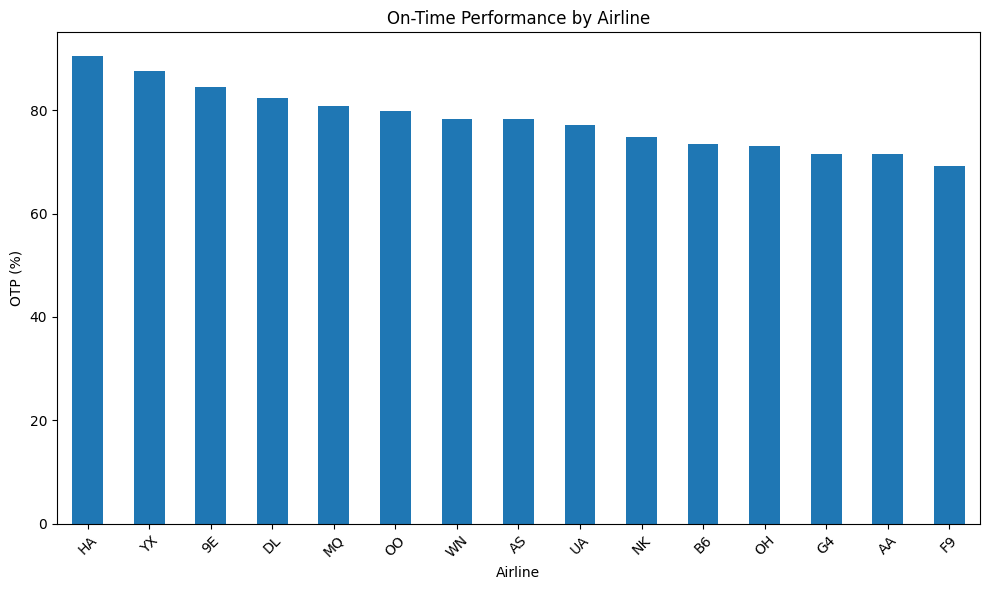

<Figure size 640x480 with 0 Axes>

In [28]:
plt.figure(figsize=(10,6))

airline_summary["OTP"].plot(kind="bar")

plt.title("On-Time Performance by Airline")
plt.ylabel("OTP (%)")
plt.xlabel("Airline")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
plt.savefig("../images/airline_otp.png", dpi=300, bbox_inches="tight")

## Key Findings

- ...
- ...
- ...

## Business Insight

...

# Airport Performance Analysis

## Business Question

How does operational performance differ across origin airports?

In [14]:
airport_summary = (
    df.groupby("origin")
      .agg(
          Flights=("arr_delay", "count"),
          OTP=("arr_delay", lambda x: (x <= 15).mean() * 100),
          Avg_Arrival_Delay=("arr_delay", "mean"),
          Avg_Departure_Delay=("dep_delay", "mean"),
          Cancellation_Rate=("cancelled", "mean"),
      )
      .round(2)
)

airport_summary = airport_summary.sort_values(
    by="Avg_Arrival_Delay",
    ascending=False
)

airport_summary.head(10)

,Flights,OTP,Avg_Arrival_Delay,Avg_Departure_Delay,Cancellation_Rate
origin,,,,,
VCT,2,50.00,152.00,153.50,0.00
FLG,2,0.00,117.00,108.50,0.00
ADQ,1,0.00,105.00,116.00,0.00
SCK,1,0.00,105.00,100.00,0.00
MOT,6,57.14,104.17,111.83,0.14
YUM,4,75.00,98.75,103.25,0.00
PSE,3,33.33,95.33,91.67,0.00
MBS,6,66.67,92.67,97.67,0.00
ICT,16,68.75,74.69,72.75,0.00


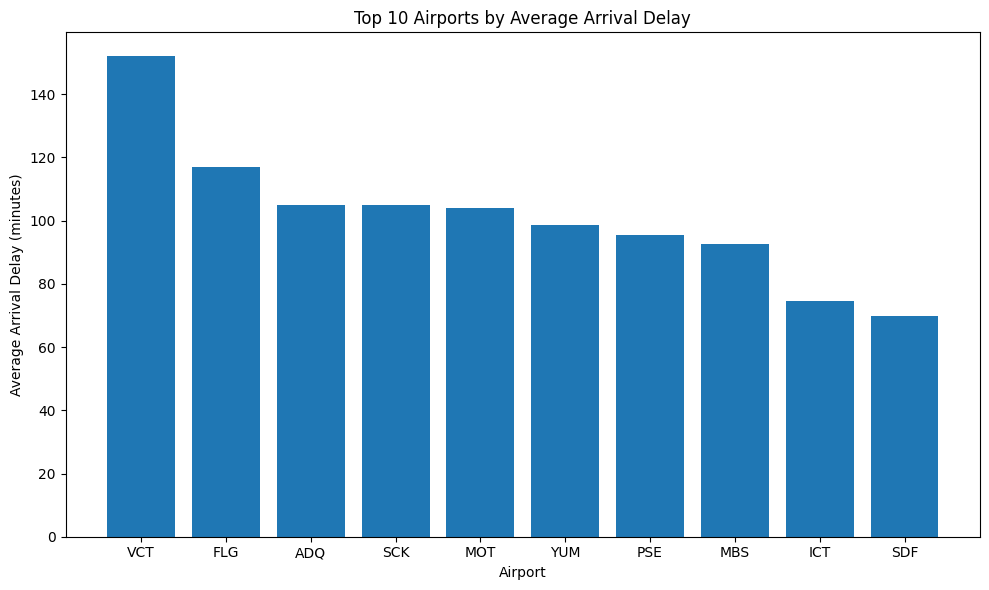

<Figure size 640x480 with 0 Axes>

In [29]:
top10 = airport_summary.head(10)

plt.figure(figsize=(10,6))

plt.bar(top10.index, top10["Avg_Arrival_Delay"])

plt.title("Top 10 Airports by Average Arrival Delay")
plt.xlabel("Airport")
plt.ylabel("Average Arrival Delay (minutes)")

plt.tight_layout()
plt.show()
plt.savefig("../images/airline_otp.png", dpi=300, bbox_inches="tight")

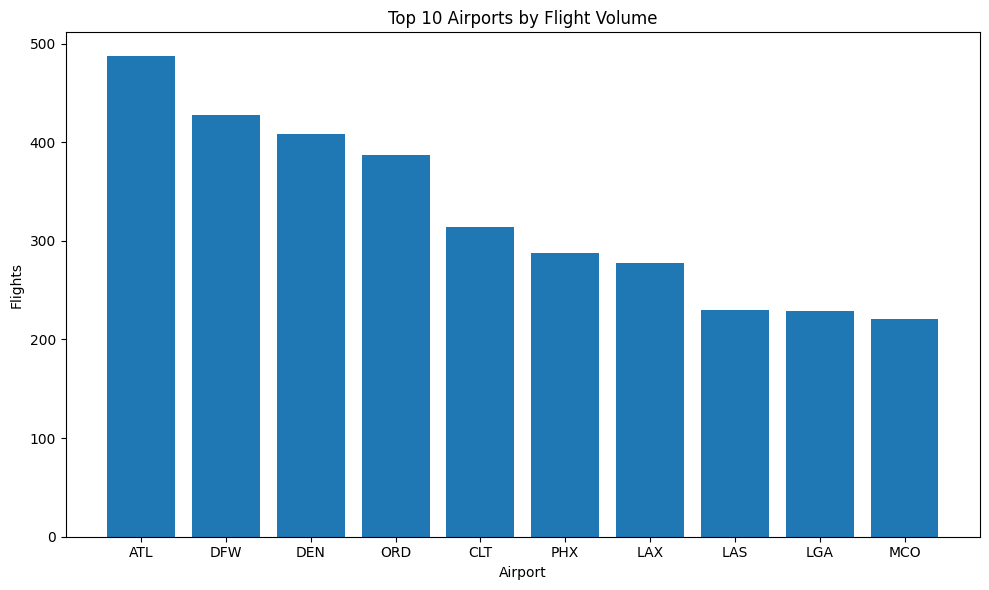

<Figure size 640x480 with 0 Axes>

In [31]:
top_volume = airport_summary.sort_values(
    by="Flights",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.bar(top_volume.index, top_volume["Flights"])

plt.title("Top 10 Airports by Flight Volume")
plt.xlabel("Airport")
plt.ylabel("Flights")

plt.tight_layout()
plt.show()
plt.savefig("../images/airline_otp.png", dpi=300, bbox_inches="tight")


## Key Findings

- ...
- ...

## Business Insight

...

# Delay Root Cause Analysis

## Business Question

Which operational factors contribute most to flight delays?

In [17]:
delay_causes = pd.DataFrame({
    "Delay Cause": [
        "Carrier",
        "Weather",
        "NAS",
        "Security",
        "Late Aircraft"
    ],
    "Total Delay Minutes": [
        df["carrier_delay"].sum(),
        df["weather_delay"].sum(),
        df["nas_delay"].sum(),
        df["security_delay"].sum(),
        df["late_aircraft_delay"].sum()
    ]
})

delay_causes = delay_causes.sort_values(
    by="Total Delay Minutes",
    ascending=False
)

delay_causes

,Delay Cause,Total Delay Minutes
4,Late Aircraft,61422
0,Carrier,48709
2,NAS,30271
1,Weather,10831
3,Security,88


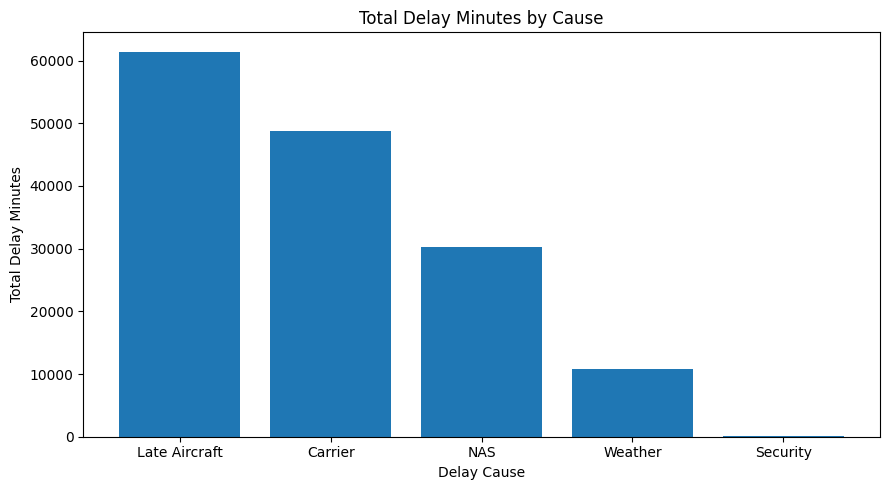

<Figure size 640x480 with 0 Axes>

In [32]:
plt.figure(figsize=(9,5))

plt.bar(
    delay_causes["Delay Cause"],
    delay_causes["Total Delay Minutes"]
)

plt.title("Total Delay Minutes by Cause")
plt.xlabel("Delay Cause")
plt.ylabel("Total Delay Minutes")

plt.tight_layout()
plt.show()
plt.savefig("../images/airline_otp.png", dpi=300, bbox_inches="tight")

In [19]:
delay_causes["Contribution (%)"] = (
    delay_causes["Total Delay Minutes"]
    / delay_causes["Total Delay Minutes"].sum()
    * 100
).round(2)

delay_causes

,Delay Cause,Total Delay Minutes,Contribution (%)
4,Late Aircraft,61422,40.59
0,Carrier,48709,32.19
2,NAS,30271,20.00
1,Weather,10831,7.16
3,Security,88,0.06


## Key Findings

- ...
- ...

## Business Insight

Understanding the dominant delay sources helps airline management prioritize operational improvement initiatives where they will have the greatest impact.

# Time-Based Analysis

## Business Question

How does operational performance change throughout the year?

In [20]:
monthly_delay = (
    df.groupby("month")
      .agg(
          Flights=("arr_delay", "count"),
          Avg_Arrival_Delay=("arr_delay", "mean"),
          OTP=("arr_delay", lambda x: (x <= 15).mean() * 100)
      )
      .round(2)
)

monthly_delay

,Flights,Avg_Arrival_Delay,OTP
month,,,
1,717,10.35,72.31
2,709,-0.33,85.20
3,828,7.93,77.51
4,845,6.58,78.86
5,823,12.84,75.51
6,822,11.63,72.54
7,882,21.49,66.41
8,857,9.99,76.93
9,831,0.94,84.69


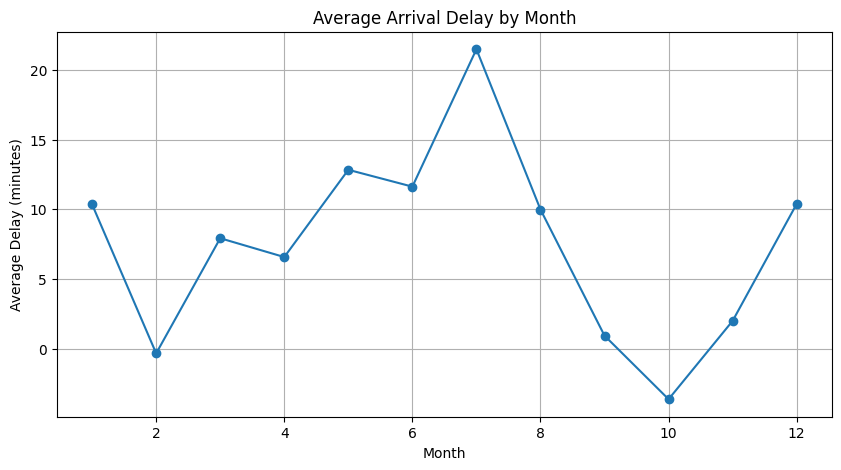

<Figure size 640x480 with 0 Axes>

In [33]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_delay.index,
    monthly_delay["Avg_Arrival_Delay"],
    marker="o"
)

plt.title("Average Arrival Delay by Month")
plt.xlabel("Month")
plt.ylabel("Average Delay (minutes)")

plt.grid(True)

plt.show()
plt.savefig("../images/airline_otp.png", dpi=300, bbox_inches="tight")

In [22]:
weekly_delay = (
    df.groupby("day_of_week")
      .agg(
          Avg_Arrival_Delay=("arr_delay", "mean"),
          OTP=("arr_delay", lambda x: (x <= 15).mean() * 100)
      )
      .round(2)
)

weekly_delay

,Avg_Arrival_Delay,OTP
day_of_week,,
1,6.43,79.31
2,3.09,81.00
3,4.64,80.70
4,8.89,75.39
5,9.98,75.56
6,9.57,77.77
7,10.04,76.38


# Operational Insights

## Business Question

Based on the analyses performed so far, what are the most important operational findings and where should airline management focus improvement efforts?

In [23]:
airline_summary.nlargest(5, "OTP")

,Flights,OTP,Avg_Arrival_Delay,Avg_Departure_Delay,Cancellation_Rate
op_unique_carrier,,,,,
HA,94,90.53,0.43,1.84,0.01
YX,426,87.56,-3.16,1.79,0.01
9E,272,84.53,4.08,10.62,0.02
DL,1443,82.39,3.55,10.16,0.01
MQ,399,80.79,4.89,8.45,0.01


In [24]:
airline_summary.nsmallest(5, "OTP")

,Flights,OTP,Avg_Arrival_Delay,Avg_Departure_Delay,Cancellation_Rate
op_unique_carrier,,,,,
F9,288,69.15,15.90,18.86,0.02
AA,1360,71.48,16.20,21.99,0.02
G4,170,71.51,9.73,12.84,0.01
OH,316,73.01,13.57,16.68,0.03
B6,328,73.41,11.41,17.59,0.00


In [25]:
airport_summary.nlargest(10, "Avg_Arrival_Delay")

,Flights,OTP,Avg_Arrival_Delay,Avg_Departure_Delay,Cancellation_Rate
origin,,,,,
VCT,2,50.00,152.00,153.50,0.00
FLG,2,0.00,117.00,108.50,0.00
ADQ,1,0.00,105.00,116.00,0.00
SCK,1,0.00,105.00,100.00,0.00
MOT,6,57.14,104.17,111.83,0.14
YUM,4,75.00,98.75,103.25,0.00
PSE,3,33.33,95.33,91.67,0.00
MBS,6,66.67,92.67,97.67,0.00
ICT,16,68.75,74.69,72.75,0.00


In [26]:
delay_causes.sort_values(
    by="Contribution (%)",
    ascending=False
)

,Delay Cause,Total Delay Minutes,Contribution (%)
4,Late Aircraft,61422,40.59
0,Carrier,48709,32.19
2,NAS,30271,20.00
1,Weather,10831,7.16
3,Security,88,0.06


## Key Findings

- The airlines with the highest OTP demonstrate more reliable operational performance.
- A limited number of airports contribute disproportionately to arrival delays.
- Carrier Delay and Late Aircraft Delay are the dominant operational delay sources.
- Improving controllable operational processes is likely to produce the greatest performance gains.

## Business Insight

Operational performance is influenced by multiple interconnected factors. While external conditions such as weather cannot be controlled, delays related to airline operations and aircraft utilization represent significant opportunities for operational improvement.

## Management Recommendations

- Prioritize reduction of Carrier Delay through operational process improvements.
- Improve aircraft turnaround efficiency to reduce Late Aircraft Delay.
- Closely monitor airports with consistently poor operational performance.
- Establish KPI dashboards to continuously track operational performance.

# Executive Dashboard

## Business Objective

Provide airline executives with a concise overview of operational performance through key performance indicators and visual analytics.

In [27]:
from IPython.display import display

kpi = pd.DataFrame({
    "KPI": [
        "Total Flights",
        "On-Time Performance",
        "Average Arrival Delay",
        "Average Departure Delay",
        "Cancellation Rate",
        "Diversion Rate"
    ],
    "Value": [
        f"{len(df):,}",
        f"{otp:.2f}%",
        f"{avg_arr_delay:.2f} min",
        f"{avg_dep_delay:.2f} min",
        f"{cancel_rate:.2f}%",
        f"{diversion_rate:.2f}%"
    ]
})

display(kpi)

,KPI,Value
0,Total Flights,"10,000"
1,On-Time Performance,77.96%
2,Average Arrival Delay,7.55 min
3,Average Departure Delay,13.00 min
4,Cancellation Rate,1.22%
5,Diversion Rate,0.42%


## Executive Dashboard Visualizations

The following charts summarize the airline's operational performance:

- On-Time Performance by Airline
- Average Arrival Delay by Airport
- Delay Causes
- Monthly Arrival Delay Trend

## Executive Summary

This dashboard provides a high-level assessment of airline operational performance using real flight operations data.

Overall performance is evaluated through operational KPIs, airline benchmarking, airport benchmarking, temporal analysis, and delay root cause analysis.

The results highlight operational strengths, identify performance bottlenecks, and support data-driven decision making.

# Conclusion

## Project Summary

This project analyzed airline operational performance using real-world flight operations data from the BTS Flight Data 2024 dataset.

The analysis focused on operational KPIs, airline and airport performance, delay root causes, and temporal patterns. The findings provide actionable insights that can support airline operational decision-making and continuous performance improvement.

# Future Work

Future improvements for this project may include:

- Flight Delay Prediction using Machine Learning
- Interactive Power BI Dashboard
- Route Performance Analysis
- Aircraft Utilization Analysis
- Predictive Maintenance Integration
- Real-Time Operational Monitoring

# Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

# References

- Bureau of Transportation Statistics (BTS)
- Flight Data 2024 Dataset